# Fair Lending Project - Seattle University

Exploratory Data Analysis - Census Annual Business Survey (ABS) And FRED Economic Data 

## Import Libraries

In [3]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from io import BytesIO
import requests

## Environment Setup

In [4]:
db_fred_path = '../data/fred_indicators.db'
db_census_path = '../data/sba_census.db'

db_census_url = 'https://www.dropbox.com/scl/fi/n3kq9j0cmncf05l1r8y12/sba_census.db?rlkey=1weab5lkylssqnb71xb47tlay&dl=1'
db_fred_url = 'https://www.dropbox.com/scl/fi/73whajs6vtycejpjut8s9/fred_indicators.db?rlkey=2x1caljfbt7h60b9nai8x14vq&dl=1'

## Download Databases

In [5]:
#Cache data locally if not already present
if not os.path.exists(db_fred_path):
    print("Downloading fred_indicators.db ...")
    response = requests.get(db_fred_url)
    response.raise_for_status()
    with open(db_fred_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded fred_indicators.db")
else:
    print("fred_indicators.db already exists.")

if not os.path.exists(db_census_path):
    print("Downloading sba_census.db ...")
    response = requests.get(db_census_url)
    response.raise_for_status()
    with open(db_census_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded sba_census.db.")
else:
    print("sba_census.db already exists.")

fred_indicators.db already exists.
sba_census.db already exists.


## Define Aggregation SQL Views

Aggregates business segment metrics by state and industry, including average percentages of women, minority, and veteran ownership, as well as average revenue and employee counts per firm. This view summarizes demographic and economic characteristics for each business segment across selected years

In [16]:
# Create a Permanent  View 
create_view_sql = """
DROP VIEW IF EXISTS V_CENSUS_BUSINESS_SEGMENTS;

CREATE VIEW V_CENSUS_BUSINESS_SEGMENTS AS
WITH Yearly_Base AS (
    -- Define the baseline totals (denominators) for each Year, State, and Sector.
    -- We filter for rows where all demographics are 'all firms' to get the segment-wide totals.
    SELECT 
        obs.Year,
        obs.State_Code,
        obs.NAICS_Code as Sector,
        obs.Demographic_Profile_ID,
        CAST(obs.Firm_Count AS REAL) as total_firms,
        CAST(obs.Revenue AS REAL) as total_rev,
        CAST(obs.Employee_Count AS REAL) as total_emp
    FROM CENSUS_OBSERVATION obs
    JOIN DEMOGRAPHIC_PROFILE dp ON obs.Demographic_Profile_ID = dp.Profile_ID
    WHERE LOWER(TRIM(dp.Gender_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Race_Group_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Eth_Group_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Vet_Group_Desc)) = 'all firms'
      AND obs.Year IN (2002, 2007, 2012)
),
Demographic_Slices AS (
    -- Aggregate counts for specific demographic subgroups (numerators).
    -- We use conditional aggregation (SUM/CASE) to pivot long demographic rows into wide columns.
    SELECT 
        obs.Year,
        obs.State_Code,
        obs.NAICS_Code as Sector,
        SUM(CASE WHEN LOWER(dp.Gender_Desc) LIKE '%female%' THEN obs.Firm_Count ELSE 0 END) as women_firms,
        SUM(CASE WHEN LOWER(dp.Race_Group_Desc) LIKE '%minority%' OR LOWER(dp.Eth_Group_Desc) LIKE '%hispanic%' THEN obs.Firm_Count ELSE 0 END) as minority_firms,
        SUM(CASE WHEN LOWER(dp.Vet_Group_Desc) LIKE '%veteran%' THEN obs.Firm_Count ELSE 0 END) as vet_firms
    FROM CENSUS_OBSERVATION obs
    JOIN DEMOGRAPHIC_PROFILE dp ON obs.Demographic_Profile_ID = dp.Profile_ID
    GROUP BY 1, 2, 3
),
Yearly_Metrics AS (
    -- Combine totals and slices to calculate percentages and economic density ratios.
    -- We use LEFT JOIN to ensure segments with 0 subgroup firms are still included.
    SELECT 
        b.Year,
        b.State_Code,
        b.Sector,
        b.Demographic_Profile_ID,
        (CAST(COALESCE(d.women_firms, 0) AS REAL) / b.total_firms) as pct_women,
        (CAST(COALESCE(d.minority_firms, 0) AS REAL) / b.total_firms) as pct_minority,
        (CAST(COALESCE(d.vet_firms, 0) AS REAL) / b.total_firms) as pct_vet,
        (b.total_rev / b.total_firms) as rev_per_firm,
        (b.total_emp / b.total_firms) as emp_per_firm
    FROM Yearly_Base b
    LEFT JOIN Demographic_Slices d ON b.Year = d.Year 
      AND b.State_Code = d.State_Code 
      AND b.Sector = d.Sector
    WHERE b.total_firms > 0
)
-- Average the yearly metrics to create the single proxy for each segment.
-- This collapses the 2002, 2007, and 2012 data into multi-year averages.
SELECT 
    State_Code,
    Sector,
    Demographic_Profile_ID,
    AVG(pct_women) as avg_pct_women,
    AVG(pct_minority) as avg_pct_minority,
    AVG(pct_vet) as avg_pct_vet,
    AVG(rev_per_firm) as avg_rev_per_firm,
    AVG(emp_per_firm) as avg_emp_per_firm
FROM Yearly_Metrics
GROUP BY State_Code, Sector;
"""

conn = sqlite3.connect(db_census_path)

conn.executescript(create_view_sql)
print("SQL View 'V_CENSUS_BUSINESS_SEGMENTS' created successfully.")

conn.close()

SQL View 'V_CENSUS_BUSINESS_SEGMENTS' created successfully.


The V_FRED_MACRO_INDICATORS view shows Macroeconomic situation. It provides economic indicators: Unemployment, CPI, Federal Funds, and the Prime Rate—the  It utilizes SQL window functions to derive Year-over-Year Inflation, computes the Prime-Funds Spread to measure bank lending premiums, and determines the Real Interest Rate to assess the actual debt burden on businesses.

In [17]:

# Create a SQL View for Macro Indicators
create_view_sql = """
DROP VIEW IF EXISTS V_FRED_MACRO_INDICATORS;

CREATE VIEW V_FRED_MACRO_INDICATORS AS
WITH Pivoted_Base AS (
    -- CTE 1: Pivot the long FRED observations into a wide format by Year
    SELECT 
        Year,
        MAX(CASE WHEN Series_ID = 'UNRATE'   THEN Yearly_Value END) AS unemployment_rate,
        MAX(CASE WHEN Series_ID = 'CPIAUCSL' THEN Yearly_Value END) AS cpi_index,
        MAX(CASE WHEN Series_ID = 'FEDFUNDS' THEN Yearly_Value END) AS fed_funds_rate,
        MAX(CASE WHEN Series_ID = 'MPRIME'   THEN Yearly_Value END) AS prime_rate
    FROM FRED_OBSERVATION_YEARLY
    GROUP BY Year
),
Macro_Calculations AS (
    -- Calculate YoY Inflation and Interest Rate Spreads
    -- LAG() allows to calculate the percentage change in CPI index for inflation
    SELECT 
        Year,
        unemployment_rate,
        fed_funds_rate,
        prime_rate,
        ((cpi_index - LAG(cpi_index) OVER (ORDER BY Year)) / LAG(cpi_index) OVER (ORDER BY Year)) * 100 AS inflation_yoy,
        (prime_rate - fed_funds_rate) AS prime_funds_spread
    FROM Pivoted_Base
)
-- Clean up and calculate the "Real Interest Rate"
SELECT 
    Year,
    unemployment_rate,
    fed_funds_rate,
    prime_rate,
    ROUND(inflation_yoy, 2) AS inflation_yoy,
    ROUND(prime_funds_spread, 2) AS prime_funds_spread,
    ROUND(prime_rate - COALESCE(inflation_yoy, 0), 2) AS real_interest_rate
FROM Macro_Calculations;
"""

conn = sqlite3.connect(db_fred_path)

conn.executescript(create_view_sql)
print("SQL View 'V_FRED_MACRO_INDICATORS' created successfully.")
conn.close()


SQL View 'V_FRED_MACRO_INDICATORS' created successfully.


## Load Data

In [18]:
conn = sqlite3.connect(db_census_path)
df_census_segment_avg = pd.read_sql_query("SELECT * FROM V_CENSUS_BUSINESS_SEGMENTS", conn)
conn.close()

print(f"Loaded {len(df_census_segment_avg)} industry-state segments from the SQL View.")


Loaded 1020 industry-state segments from the SQL View.


In [19]:
df_census_segment_avg.describe(include='all')

,State_Code,Sector,Demographic_Profile_ID,avg_pct_women,avg_pct_minority,avg_pct_vet,avg_rev_per_firm,avg_emp_per_firm
count,1020,1020,1020.0,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
unique,51,20,NaN,NaN,NaN,NaN,NaN,NaN
top,AK,11,NaN,NaN,NaN,NaN,NaN,NaN
freq,20,51,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.0,1.416468,3.719163,1.885385,2960.043533,10.126065
std,NaN,NaN,0.0,0.574359,0.518920,0.281354,6140.423940,17.689971
min,NaN,NaN,1.0,0.151322,1.012314,0.483221,0.000000,0.000000
25%,NaN,NaN,1.0,1.006409,3.711499,1.883090,221.600577,1.812823
50%,NaN,NaN,1.0,1.425688,3.863994,1.935766,627.716244,5.180650
75%,NaN,NaN,1.0,1.895437,3.979050,1.978571,2739.397049,9.714701


In [42]:
df_census_segment_avg['Sector'].unique()

array(['11', '21', '22', '23', '31-33', '42', '44-45', '48-49', '51',
       '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '99'],
      dtype=object)

In [28]:
conn = sqlite3.connect(db_fred_path)

fred_df = pd.read_sql_query("SELECT * FROM V_FRED_MACRO_INDICATORS", conn)
conn.close()

print(f"Loaded {len(fred_df)} years of macroeconomic data.")
display(fred_df.tail())

Loaded 28 years of macroeconomic data.


,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
23,2010,9.608333,0.175000,3.25,1.64,3.08,1.61
24,2011,8.933333,0.101667,3.25,3.14,3.15,0.11
25,2012,8.075000,0.140000,3.25,2.07,3.11,1.18
26,2013,7.358333,0.107500,3.25,1.47,3.14,1.78
27,2014,6.158333,0.089167,3.25,1.62,3.16,1.63


In [29]:
fred_df.describe()

,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
count,28.000000,28.000000,28.000000,28.000000,27.000000,28.000000,28.000000
mean,2000.500000,6.075000,3.752054,6.579286,2.763704,2.827143,3.914643
std,8.225975,1.502645,2.712536,2.403321,1.164144,0.473841,2.034316
min,1987.000000,3.966667,0.089167,3.250000,-0.320000,1.550000,0.110000
25%,1993.750000,5.047917,1.293750,4.286875,2.130000,2.962500,1.810000
50%,2000.500000,5.700000,4.044583,7.030000,2.820000,2.990000,4.180000
75%,2007.250000,6.864583,5.516875,8.376042,3.295000,3.042500,5.447500
max,2014.000000,9.608333,9.216667,10.873333,5.420000,3.160000,8.200000


## Exploratory Analysis

### Census

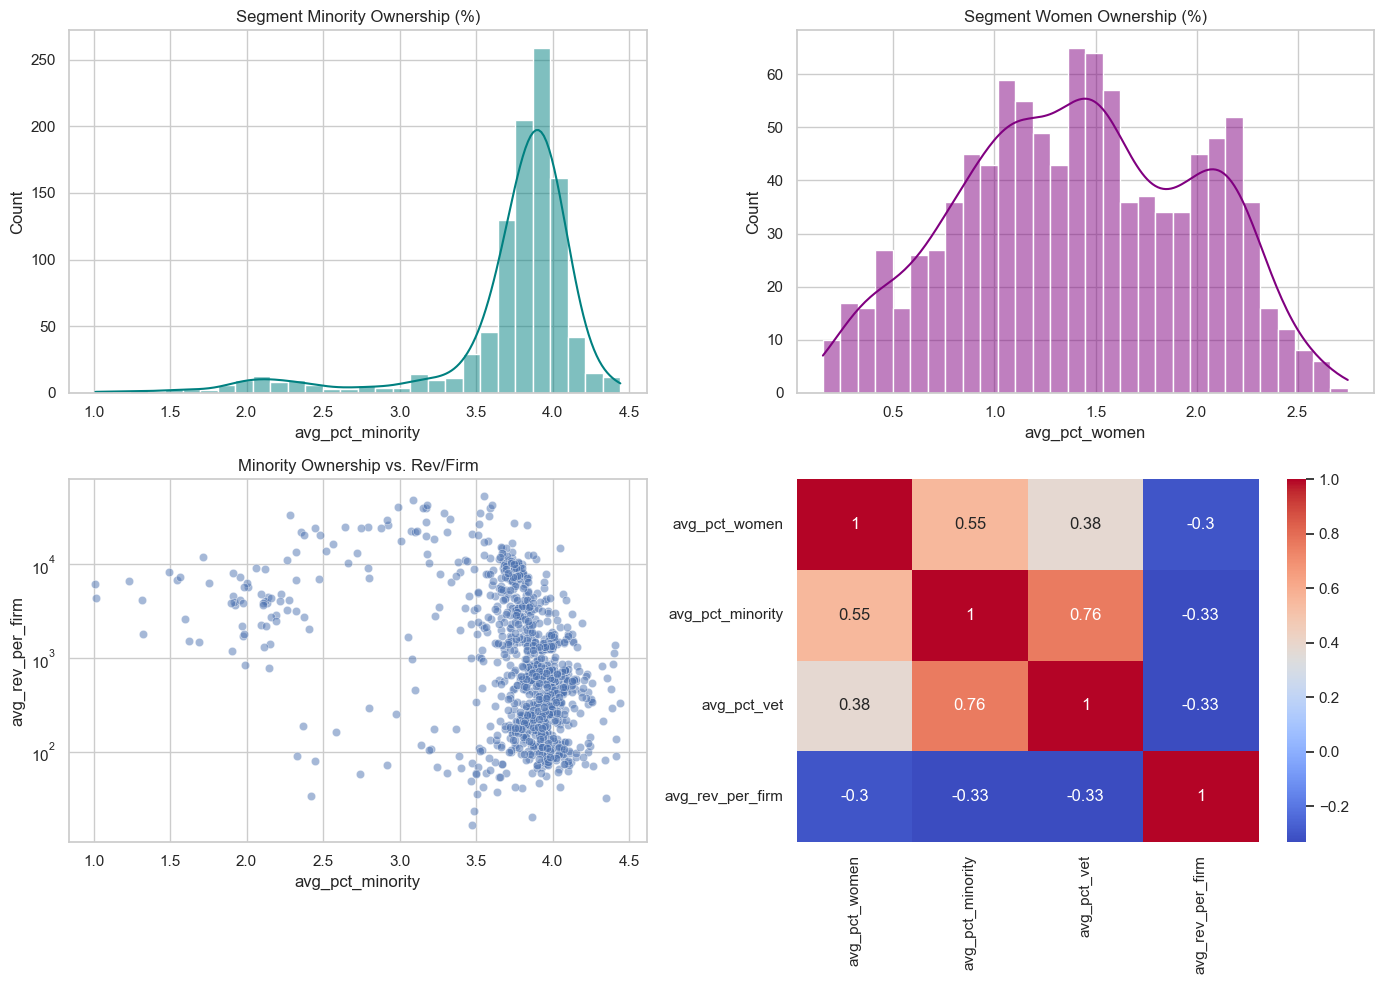

In [24]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_census_segment_avg['avg_pct_minority'], bins=30, ax=axes[0, 0], kde=True, color='teal')
axes[0, 0].set_title('Segment Minority Ownership (%)')
sns.histplot(df_census_segment_avg['avg_pct_women'], bins=30, ax=axes[0, 1], kde=True, color='purple')
axes[0, 1].set_title('Segment Women Ownership (%)')
sns.scatterplot(data=df_census_segment_avg, x='avg_pct_minority', y='avg_rev_per_firm', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Minority Ownership vs. Rev/Firm')
corr = df_census_segment_avg[['avg_pct_women', 'avg_pct_minority', 'avg_pct_vet', 'avg_rev_per_firm']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 1])
plt.tight_layout()
plt.show()

**Ownership Distributions**

- **Minority Ownership:** The distribution is heavily skewed toward the right (higher percentages). This suggests that most of your industry-state segments have a substantial presence of minority-owned firms, but there is a distinct "long tail" of segments with very low representation.

- **Women Ownership:** This looks more like a bimodal or normal distribution. It shows a broad range of representation across segments, suggesting that gender ownership varies more consistently across different states and industries than racial ownership does.

- **Minority Ownership vs. Revenue Density**
There appears to be a negative correlation between the concentration of minority-owned firms and the average revenue per firm in that segment.
As the avg_pct_minority increases, the avg_rev_per_firm tends to cluster at lower values (log scale).

Strategy Insight: This confirms a structural disparity. Segments with higher minority ownership are often characterized by smaller firms (in terms of revenue).

- **Correlation Matrix (Bottom Right)**
 Strong Positive Correlation (0.76): There is a very strong link between avg_pct_minority and avg_pct_vet. This suggests that segments (industries/states) that support minority-owned businesses also tend to have high veteran ownership.

Moderate Correlation (0.55): There is a positive link between women ownership and minority ownership.

Negative Correlation (-0.3 to -0.33): All three demographic categories (Women, Minority, Veteran) show a negative correlation with avg_rev_per_firm. This statistically reinforces the scatter plot observation: demographics associated with equity initiatives are currently concentrated in segments with lower average firm revenues.

**Summary** 
This shows that segments carries real economic weight. It will be critical to account for these structural correlations, a standard ML model might inadvertently learn to use "Geography/Industry" as a proxy for demographics, leading to biased lending predictions.

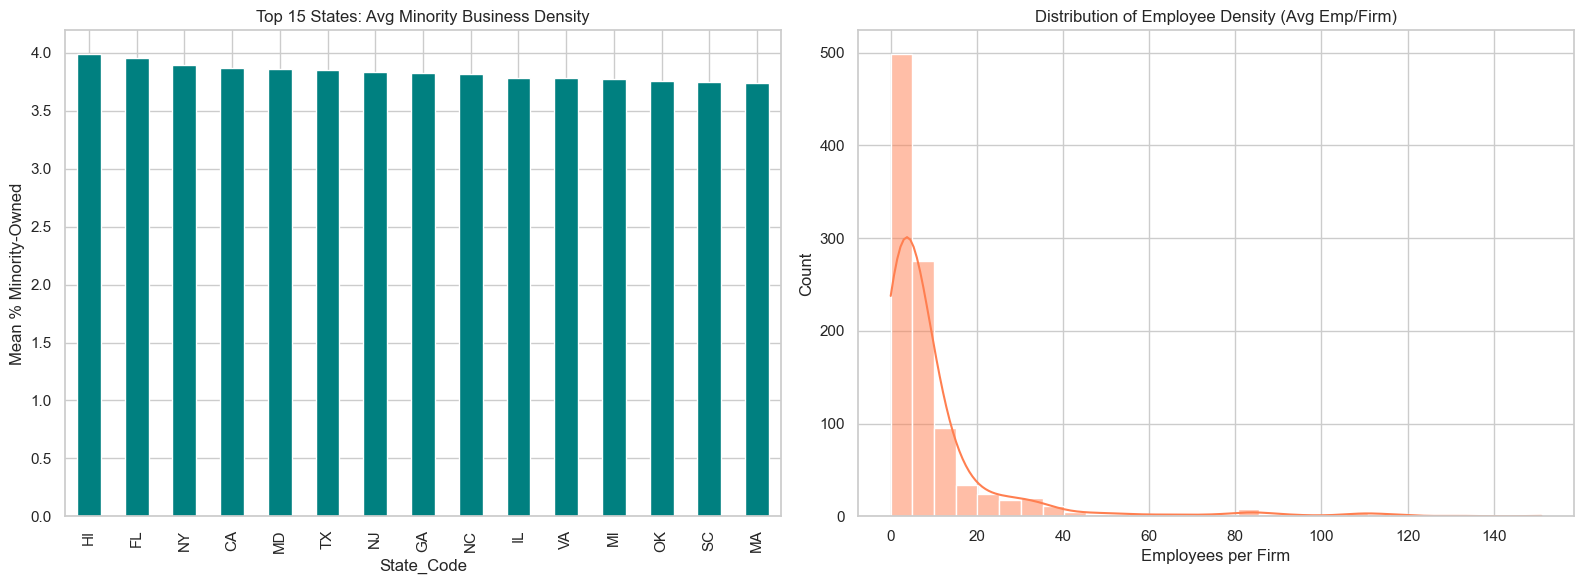

In [26]:
# Figure 2: Regional and Sectoral Variation
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# 5. Top 15 States by Minority-Owned Business Density
state_minority = df_census_segment_avg.groupby('State_Code')['avg_pct_minority'].mean().sort_values(ascending=False).head(15)
state_minority.plot(kind='bar', ax=axes2[0], color='teal')
axes2[0].set_title('Top 15 States: Avg Minority Business Density')
axes2[0].set_ylabel('Mean % Minority-Owned')

# 6. Distribution of Employee Density
sns.histplot(df_census_segment_avg['avg_emp_per_firm'], bins=30, ax=axes2[1], kde=True, color='coral')
axes2[1].set_title('Distribution of Employee Density (Avg Emp/Firm)')
axes2[1].set_xlabel('Employees per Firm')

plt.tight_layout()
plt.show()


**Top 15 States: Average Minority Business Density**
Geographic Concentration: Hawaii (HI) leads with the highest density, followed by Florida (FL), New York (NY), California (CA), and Maryland (MD).It suggests that minority business ownership is structurally significant across the most populous U.S. states.

**Distribution of Employee Density (Avg Emp/Firm)**
The "Small" in Small Business: The vast majority of industry-state segments average between 0 and 20 employees per firm, with a very sharp peak under 10.
Outlier Segments: There is a "long tail" extending out to 140+ employees. 

It is important to take into consideration, that size of the business is relative. In segment where average number of employees is 20, 10 employees could be considered small, but in segment with 3 employees, business with 10 employees can be considered large.

### FRED

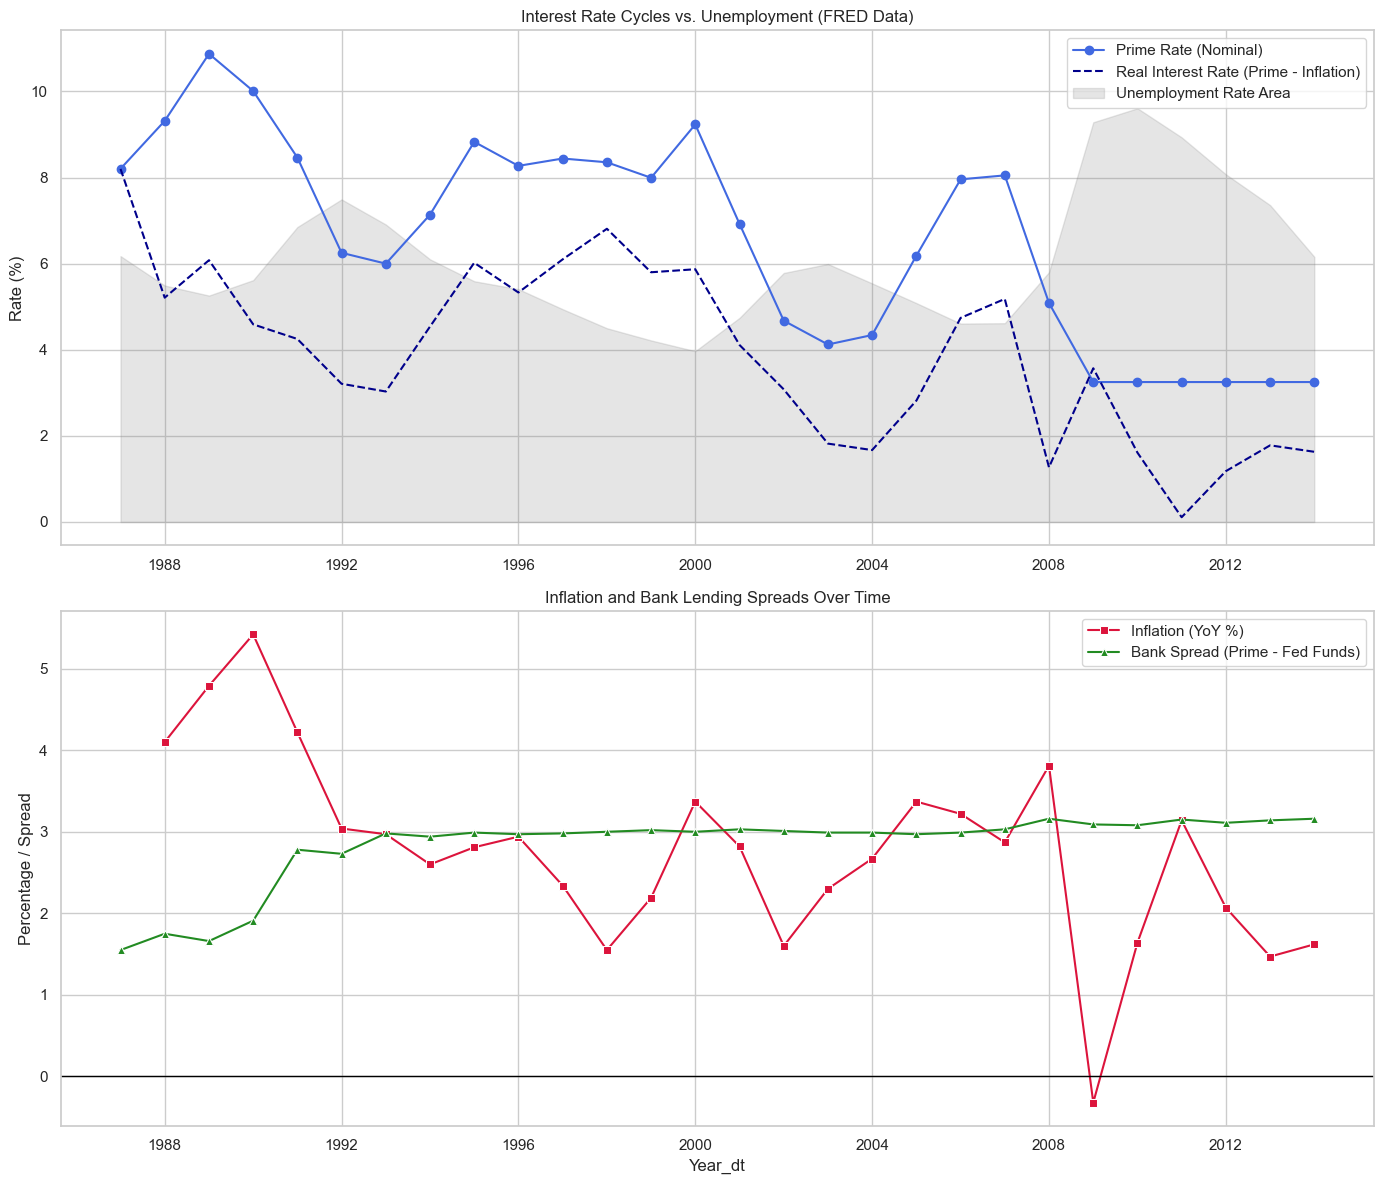

In [32]:
# Convert Year to datetime 
fred_df['Year_dt'] = pd.to_datetime(fred_df['Year'], format='%Y')

# Macroeconomic Trend Analysis
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Interest Rate Trends (Nominal vs Real)
axes[0].plot(fred_df['Year_dt'], fred_df['prime_rate'], label='Prime Rate (Nominal)', marker='o', color='royalblue')
axes[0].plot(fred_df['Year_dt'], fred_df['real_interest_rate'], label='Real Interest Rate (Prime - Inflation)', linestyle='--', color='darkblue')
axes[0].fill_between(fred_df['Year_dt'], fred_df['unemployment_rate'], alpha=0.2, color='gray', label='Unemployment Rate Area')
axes[0].set_title('Interest Rate Cycles vs. Unemployment (FRED Data)')
axes[0].set_ylabel('Rate (%)')
axes[0].legend()

# Economic Pressure Indicators
sns.lineplot(data=fred_df, x='Year_dt', y='inflation_yoy', ax=axes[1], label='Inflation (YoY %)', color='crimson', marker='s')
sns.lineplot(data=fred_df, x='Year_dt', y='prime_funds_spread', ax=axes[1], label='Bank Spread (Prime - Fed Funds)', color='forestgreen', marker='^')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Inflation and Bank Lending Spreads Over Time')
axes[1].set_ylabel('Percentage / Spread')

plt.tight_layout()
plt.show()



**Interest Rate Cycles vs. Unemployment**
This plot tracks the cost of capital against general labor market distress.

**The Debt Burden:** In the late 1980s, even though nominal rates were over 10%, high inflation made the "real" cost of borrowing about 8%. By 2010, the real rate hit nearly 0%, meaning debt was essentially free in real terms. Loans approved in the late 80s or mid-2000s faced a "rising rate" environment shortly after origination. The post-2008 period was a "low-rate" environment, which helped businesses stay afloat despite the high unemployment.

**Inflation and Bank Lending Spreads**
This plot focuses on price volatility and how banks "price" risk. 

**The 3% Standard:** Since the mid-1990s, rate spread has stayed almost perfectly flat at 3.0%. The Early 90s Exception: Before 1994, the spread was much narrower and more volatile. This suggests that the "pricing" of SBA loans might have been fundamentally different in the earliest part (1987–1993) compared to the later years.


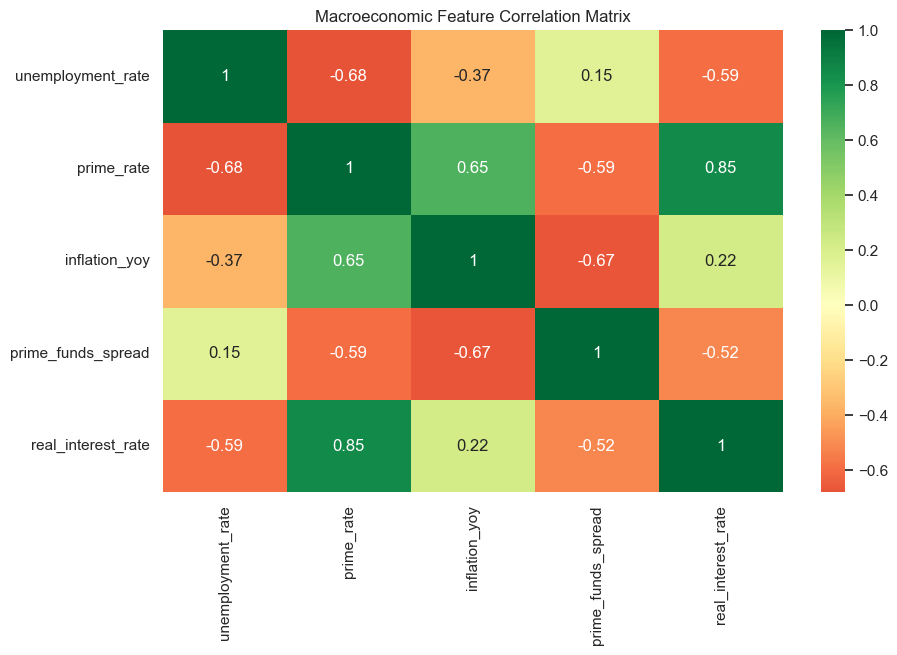

In [31]:
# Correlation with Business Cycles
plt.figure(figsize=(10, 6))
corr = fred_df[['unemployment_rate', 'prime_rate', 'inflation_yoy', 'prime_funds_spread', 'real_interest_rate']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Macroeconomic Feature Correlation Matrix')
plt.show()

**The Strongest correlation:** Prime Rate & Real Interest Rate (0.85). This very high positive correlation is expected. Since the real_interest_rate is derived from the prime_rate, they move in lockstep.

**Unemployment’s Negative Relationships**
Unemployment vs. Prime Rate (-0.68) perfectly illustrates Federal Reserve policy. When unemployment is high , the Fed lowers interest rates to stimulate growth. When unemployment is low (overheating economy), they raise rates.

**Inflation vs. The Prime-Funds Spread**
Negative correlation suggests that when inflation is high, the "Bank Spread" (the markup banks charge over the base rate) tends to compress.

